In [127]:
# Step 2

dataset_path = './dpl_pictures'
model_path = 'cnn_classifier.h5'

In [128]:
# Step 3

import importlib
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import ear_extraction
importlib.reload(ear_extraction)
from ear_extraction import extract_ear_region

In [129]:
# Step 4

image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
records = []

for class_dir in sorted(Path(dataset_path).iterdir()):
    if class_dir.is_dir():
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in image_extensions:
                records.append({
                    'filename': str(image_path),
                    'class_name': class_dir.name,
                })

dataset_df = pd.DataFrame(records)
class_order = ['b_earrings', 'b_no_earrings', 'g_earrings', 'g_no_earrings']

train_parts = []
validation_parts = []
test_parts = []

for class_name, class_df in dataset_df.groupby('class_name', sort=False):
    test_df = class_df.sample(frac=0.1, random_state=42)
    remaining_df = class_df.drop(test_df.index)
    
    validation_df_parts = remaining_df.sample(frac=0.2, random_state=42)
    train_df_class = remaining_df.drop(validation_df_parts.index)
    
    train_parts.append(train_df_class)
    validation_parts.append(validation_df_parts)
    test_parts.append(test_df)
    
    # validation_df = class_df.sample(frac=0.2, random_state=42)
    # train_df = class_df.drop(validation_df.index)
    # train_parts.append(train_df)
    # validation_parts.append(validation_df)

train_df = pd.concat(train_parts).sample(frac=1, random_state=42).reset_index(drop=True)
validation_df = pd.concat(validation_parts).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat(test_parts).sample(frac=1, random_state=42).reset_index(drop=True)

In [130]:
# Step 5

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.35,
    shear_range=0.15,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    preprocessing_function=extract_ear_region,
)

train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class_name',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    classes=class_order,
    shuffle=True,
)

print(train_data.class_indices)

Found 288 validated image filenames belonging to 4 classes.
{'b_earrings': 0, 'b_no_earrings': 1, 'g_earrings': 2, 'g_no_earrings': 3}


In [131]:
# Step 6

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=extract_ear_region,
)

validation_data = validation_datagen.flow_from_dataframe(
    validation_df,
    x_col='filename',
    y_col='class_name',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    classes=class_order,
    shuffle=False,
)

Found 72 validated image filenames belonging to 4 classes.


In [132]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=extract_ear_region,
)

test_data = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class_name',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    classes=class_order,
    shuffle=False,
)

Found 40 validated image filenames belonging to 4 classes.


In [133]:
# Step 7

base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3),
)
base_model.trainable = False

inputs = layers.Input(shape=(128, 128, 3))

x = layers.Rescaling(2.0, offset=-1.0)(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_order), activation='softmax')(x)

model = models.Model(inputs, outputs)

In [134]:
# Step 8

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [135]:
# Step 9

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

history = model.fit(
    train_data,
    epochs=20,
    validation_data=validation_data,
    callbacks=[early_stopping, reduce_lr],
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.2153 - loss: 2.4900 - val_accuracy: 0.2222 - val_loss: 1.5839 - learning_rate: 1.0000e-04
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.2882 - loss: 1.8412 - val_accuracy: 0.3889 - val_loss: 1.3566 - learning_rate: 1.0000e-04
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3542 - loss: 1.6838 - val_accuracy: 0.4306 - val_loss: 1.1744 - learning_rate: 1.0000e-04
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3785 - loss: 1.5190 - val_accuracy: 0.5972 - val_loss: 0.9825 - learning_rate: 1.0000e-04
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4688 - loss: 1.2413 - val_accuracy: 0.6389 - val_loss: 0.8566 - learning_rate: 1.0000e-04
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5243 - loss: 1.1590 - val_accuracy: 0.6806 - val_loss: 0.7800 - learning_rate: 1.0000e-04
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5417 - loss: 1.0501 - val_

In [136]:
# Fine-tune base model

base_model.trainable = True

n_unfreeze = 10
fine_tune_at = max(len(base_model.layers) - n_unfreeze, 0)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True
        
# verify
print("Total base layers:", len(base_model.layers))
print("Trainable in base:", sum(1 for l in base_model.layers if l.trainable))

Total base layers: 154
Trainable in base: 6


In [137]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_finetune.h5',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3,
    restore_best_weights=True
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = model.fit(
    train_data,
    epochs=10,
    validation_data=validation_data,
    callbacks=[checkpoint, reduce_lr, early]
)

model.load_weights('best_finetune.h5')

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8075 - loss: 0.5375

9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7951 - loss: 0.5597 - val_accuracy: 0.7778 - val_loss: 0.4184 - learning_rate: 1.0000e-05
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7983 - loss: 0.5264

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7743 - loss: 0.5511 - val_accuracy: 0.8472 - val_loss: 0.4159 - learning_rate: 1.0000e-05
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7984 - loss: 0.5090

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7847 - loss: 0.5335 - val_accuracy: 0.8472 - val_loss: 0.4074 - learning_rate: 1.0000e-05
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7725 - loss: 0.5131

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7465 - loss: 0.5462 - val_accuracy: 0.8333 - val_loss: 0.3864 - learning_rate: 1.0000e-05
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8066 - loss: 0.5716

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8125 - loss: 0.5342 - val_accuracy: 0.8333 - val_loss: 0.3592 - learning_rate: 1.0000e-05
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8459 - loss: 0.4057

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8125 - loss: 0.4669 - val_accuracy: 0.8750 - val_loss: 0.3527 - learning_rate: 1.0000e-05
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8248 - loss: 0.4350

9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8125 - loss: 0.4884 - val_accuracy: 0.8611 - val_loss: 0.3475 - learning_rate: 1.0000e-05
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8316 - loss: 0.4143

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8403 - loss: 0.4076 - val_accuracy: 0.8611 - val_loss: 0.3414 - learning_rate: 1.0000e-05
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8549 - loss: 0.4665

9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8438 - loss: 0.4550 - val_accuracy: 0.8750 - val_loss: 0.3327 - learning_rate: 1.0000e-05


In [138]:
# Step 10
loss, accuracy = model.evaluate(test_data)

print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.8750 - loss: 0.4850
Validation Accuracy: 0.875


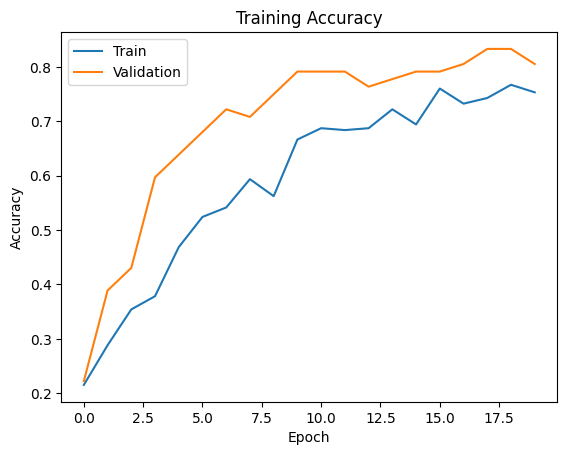

In [139]:
# Step 11
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

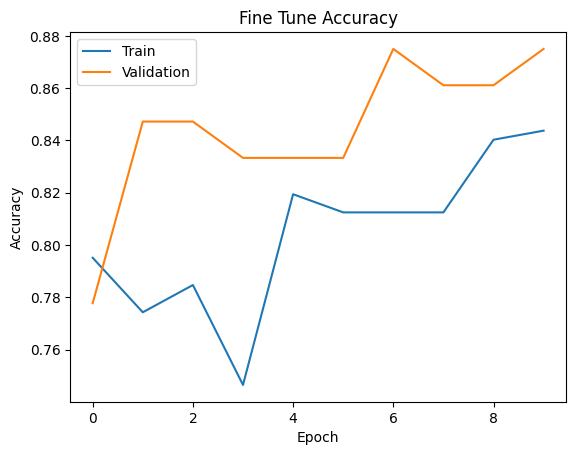

In [140]:
plt.plot(fine_tune_history.history['accuracy'])
plt.plot(fine_tune_history.history['val_accuracy'])

plt.title('Fine Tune Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [141]:
# Step 12
model.save(model_path)